In [ ]:
%pip install torch transformers datasets pandas numpy
%pip install datasets transformers torch
%pip install nltk

In [ ]:
from datasets import load_dataset, Dataset
import pandas as pd
import nltk
nltk.download('punkt') 
from nltk.tokenize import word_tokenize
from math import floor
import numpy as np
import torch
from collections import Counter
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
import seaborn as sns

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\youst\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
dataset = load_dataset("rajpurkar/squad")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})


In [4]:
train_data = dataset['train']
validation_data = dataset['validation']

# Convert the tensors to lists for each field.
train_contexts = train_data['context']
train_questions = train_data['question']
train_answers = train_data['answers']

validation_contexts = validation_data['context']
validation_questions = validation_data['question']
validation_answers = validation_data['answers']

# Combine the fields into a DataFrame
train_df = pd.DataFrame({
    'context': train_contexts,
    'question': train_questions,
    'answer': [ans['text'][0] for ans in train_answers],  # Extract the first answer
    'answer_start': [ans['answer_start'][0] for ans in train_answers]  # Extract answer start
})

validation_df = pd.DataFrame({
    'context': validation_contexts,
    'question': validation_questions,
    'answer': [ans['text'][0] for ans in validation_answers],
    'answer_start': [ans['answer_start'][0] for ans in validation_answers]
})

# Step 1: Compute the length of each context (in terms of words)
train_df['context_length'] = train_df['context'].apply(lambda x: len(x.split()))  # Length in terms of words
validation_df['context_length'] = validation_df['context'].apply(lambda x: len(x.split()))

# Step 2: Sort by the length of the context
train_df_sorted = train_df.sort_values(by='context_length')
validation_df_sorted = validation_df.sort_values(by='context_length')

# Step 3: Select the shortest 5000 contexts from train and 2000 from validation
train_selected = train_df_sorted.head(5000)
validation_selected = validation_df_sorted.head(4000)
test_selected = validation_selected.iloc[2000:]
validation_selected = validation_selected.tail(2000)

# Step 4: Convert back to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_selected[['context', 'question', 'answer', 'answer_start']])
validation_dataset = Dataset.from_pandas(validation_selected[['context', 'question', 'answer', 'answer_start']])
test_dataset = Dataset.from_pandas(test_selected[['context', 'question', 'answer', 'answer_start']])

# Step 5: Confirm the datasets
print("Train Dataset")
print(train_dataset)

print("Validation Dataset")
print(validation_dataset)

print("Test Dataset")
print(test_dataset)

Train Dataset
Dataset({
    features: ['context', 'question', 'answer', 'answer_start', '__index_level_0__'],
    num_rows: 5000
})
Validation Dataset
Dataset({
    features: ['context', 'question', 'answer', 'answer_start', '__index_level_0__'],
    num_rows: 2000
})
Test Dataset
Dataset({
    features: ['context', 'question', 'answer', 'answer_start', '__index_level_0__'],
    num_rows: 2000
})


In [5]:
# First 5 entries
print("First 5 entries:")
for i in range(5):
    print(train_dataset[i])
    print("-" * 80)

# Middle 5 entries
print("Middle 5 entries:")
middle_start = floor(len(train_dataset) / 2) - 2
for i in range(middle_start, middle_start + 5):
    print(train_dataset[i])
    print("-" * 80)

# Last 5 entries
print("Last 5 entries:")
for i in range(len(train_dataset) - 5, len(train_dataset)):
    print(train_dataset[i])
    print("-" * 80)

First 5 entries:
{'context': 'Internet services typically provided by ISPs include Internet access, Internet transit, domain name registration, web hosting, Usenet service, and colocation.', 'question': 'What type of organization provides internet access?', 'answer': 'ISPs', 'answer_start': 40, '__index_level_0__': 13934}
--------------------------------------------------------------------------------
{'context': 'Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals.', 'question': 'How many groups of modern hunter-gatherers are there?', 'answer': 'Only a few', 'answer_start': 0, '__index_level_0__': 12994}
--------------------------------------------------------------------------------
{'context': 'Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals.', 'question': 'What do modern hunt

In [ ]:
# First 10 entries
print("First 10 entries:")
for i in range(10):
    print(validation_dataset[i])
    print("-" * 80)

First 5 entries:
{'context': "Formed in 1946, Sierra Sky Park Airport is a residential airport community born of a unique agreement in transportation law to allow personal aircraft and automobiles to share certain roads. Sierra Sky Park was the first aviation community to be built[citation needed] and there are now numerous such communities across the United States and around the world. Developer William Smilie created the nation's first planned aviation community. Still in operation today, the public use airport provides a unique neighborhood that spawned interest and similar communities nationwide.", 'question': 'Are there any other aviation communities such as Sierra Sky Park in the United States?', 'answer': 'there are now numerous such communities across the United States', 'answer_start': 273, '__index_level_0__': 4763}
--------------------------------------------------------------------------------
{'context': 'His translation of the Bible into the vernacular (instead of Latin) 

In [7]:
# Function to process a DataFrame and compute tokenization and word-level start/end positions
def process_dataset(df):
    # Adjust answer_start to account for the added "Context: "
    prefix_len = len("Context: ")
    df['input'] = "Context: " + df['context'] + " Question: " + df['question']
    df['adjusted_answer_start'] = df['answer_start'] + prefix_len

    # Initialize lists
    tokenized_inputs = []
    start_word_indices = []
    end_word_indices = []

    # Iterate through each row in the DataFrame
    for i, row in df.iterrows():
        input_text = row['input']
        answer_text = row['answer']
        answer_char_start = row['adjusted_answer_start']

        # Tokenize input
        tokens = word_tokenize(input_text)
        tokenized_inputs.append(tokens)

        # Track character positions of each token
        char_positions = []
        running_char_pos = 0
        for token in tokens:
            char_index = input_text.find(token, running_char_pos)
            char_positions.append((token, char_index))
            running_char_pos = char_index + len(token)

        # Find the token index where the answer starts
        start_token_idx = None
        for idx, (tok, char_pos) in enumerate(char_positions):
            if char_pos >= answer_char_start:
                start_token_idx = idx
                break

        if start_token_idx is None:
            start_token_idx = len(tokens) - 1  # fallback

        # Tokenize answer separately to get answer length in words
        answer_tokens = word_tokenize(answer_text)
        end_token_idx = start_token_idx + len(answer_tokens) - 1

        start_word_indices.append(start_token_idx)
        end_word_indices.append(end_token_idx)

    # Add the processed data to the DataFrame
    df['input_tokens'] = tokenized_inputs
    df['answer_start_word'] = start_word_indices
    df['answer_end_word'] = end_word_indices

    return df[['input', 'input_tokens', 'answer', 'answer_start_word', 'answer_end_word']]

# Convert train, validation, and test datasets to pandas DataFrames
df_train = train_dataset.to_pandas()
df_val = validation_dataset.to_pandas()
df_test = test_dataset.to_pandas()

# Process the datasets using the reusable function
train_df = process_dataset(df_train)
val_df = process_dataset(df_val)
test_df = process_dataset(df_test)

# Print the resulting DataFrames
print(train_df.head())
print(val_df.head())
print(test_df.head())

                                               input  \
0  Context: Internet services typically provided ...   
1  Context: Only a few contemporary societies are...   
2  Context: Only a few contemporary societies are...   
3  Context: Only a few contemporary societies are...   
4  Context: Only a few contemporary societies are...   

                                        input_tokens  \
0  [Context, :, Internet, services, typically, pr...   
1  [Context, :, Only, a, few, contemporary, socie...   
2  [Context, :, Only, a, few, contemporary, socie...   
3  [Context, :, Only, a, few, contemporary, socie...   
4  [Context, :, Only, a, few, contemporary, socie...   

                                answer  answer_start_word  answer_end_word  
0                                 ISPs                  7                7  
1                           Only a few                  2                4  
2  horticulture and/or keeping animals                 19               22  
3                 

In [8]:
glove_path = "glove.6B.100d.txt"
embedding_dim = 100
glove_embeddings = {}

with open(glove_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Loading GloVe"):
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_embeddings[word] = vector

def get_embedding_sequence(tokens, embeddings_dict, embedding_dim):
    vectors = []
    for token in tokens:
        if token in embeddings_dict:
            vectors.append(embeddings_dict[token])
        else:
            # Use a zero vector if word not in GloVe
            vectors.append(np.zeros(embedding_dim))
    return np.array(vectors)

train_df['embedding_sequence'] = train_df['input_tokens'].apply(
    lambda tokens: get_embedding_sequence(tokens, glove_embeddings, embedding_dim)
)
val_df['embedding_sequence'] = val_df['input_tokens'].apply(
    lambda tokens: get_embedding_sequence(tokens, glove_embeddings, embedding_dim)
)
test_df['embedding_sequence'] = test_df['input_tokens'].apply(
    lambda tokens: get_embedding_sequence(tokens, glove_embeddings, embedding_dim)
)

print(train_df['embedding_sequence'].iloc[0].shape)  # (sequence_len, 100)


Loading GloVe: 400000it [00:14, 28483.78it/s]
C:\Users\youst\AppData\Local\Temp\ipykernel_3372\755204531.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['embedding_sequence'] = train_df['input_tokens'].apply(
C:\Users\youst\AppData\Local\Temp\ipykernel_3372\755204531.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['embedding_sequence'] = val_df['input_tokens'].apply(


(38, 100)


C:\Users\youst\AppData\Local\Temp\ipykernel_3372\755204531.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['embedding_sequence'] = test_df['input_tokens'].apply(


In [9]:
MAX_LEN = 100
EMBED_DIM = 100

# Function to process DataFrame and convert to padded embeddings and tensors
def process_for_tensor(df, glove_embeddings):
    padded_embeddings = []
    start_positions = []
    end_positions = []

    for _, row in df.iterrows():
        tokens = row['input_tokens']
        start_idx = row['answer_start_word']
        end_idx = row['answer_end_word']

        # Truncate if too long
        if len(tokens) > MAX_LEN:
            tokens = tokens[:MAX_LEN]
            if start_idx >= MAX_LEN or end_idx >= MAX_LEN:
                continue  # Skip samples where the answer is outside the range
            start_idx = min(start_idx, MAX_LEN - 1)
            end_idx = min(end_idx, MAX_LEN - 1)

        # Embed the tokens using GloVe
        embedded = [glove_embeddings.get(token, np.zeros(EMBED_DIM)) for token in tokens]

        # Padding
        pad_len = MAX_LEN - len(embedded)
        if pad_len > 0:
            embedded += [np.zeros(EMBED_DIM)] * pad_len

        padded_embeddings.append(embedded)
        start_positions.append(start_idx)
        end_positions.append(end_idx)

    # Convert to tensors
    inputs_tensor = torch.tensor(padded_embeddings, dtype=torch.float32)
    start_tensor = torch.tensor(start_positions, dtype=torch.long)
    end_tensor = torch.tensor(end_positions, dtype=torch.long)

    return inputs_tensor, start_tensor, end_tensor

# Process train_df
train_inputs_tensor, train_start_tensor, train_end_tensor = process_for_tensor(train_df, glove_embeddings)

# Process val_df
val_inputs_tensor, val_start_tensor, val_end_tensor = process_for_tensor(val_df, glove_embeddings)

# Process test_df
test_inputs_tensor, test_start_tensor, test_end_tensor = process_for_tensor(test_df, glove_embeddings)

print("Train Tensors")
print(train_inputs_tensor.shape, train_start_tensor.shape, train_end_tensor.shape)

print("Validation Tensors")
print(val_inputs_tensor.shape, val_start_tensor.shape, val_end_tensor.shape)

print("Test Tensors")
print(test_inputs_tensor.shape, test_start_tensor.shape, test_end_tensor.shape)

C:\Users\youst\AppData\Local\Temp\ipykernel_3372\1588900547.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  inputs_tensor = torch.tensor(padded_embeddings, dtype=torch.float32)


Train Tensors
torch.Size([5000, 100, 100]) torch.Size([5000]) torch.Size([5000])
Validation Tensors
torch.Size([1824, 100, 100]) torch.Size([1824]) torch.Size([1824])
Test Tensors
torch.Size([1824, 100, 100]) torch.Size([1824]) torch.Size([1824])


In [10]:
train_data = TensorDataset(train_inputs_tensor, train_start_tensor, train_end_tensor)
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)

val_data = TensorDataset(val_inputs_tensor, val_start_tensor, val_end_tensor)
val_loader = DataLoader(val_data, batch_size=8, shuffle=True)

test_data = TensorDataset(test_inputs_tensor, test_start_tensor, test_end_tensor)
test_loader = DataLoader(test_data, batch_size=8, shuffle=True)

In [11]:
class QA_Model(nn.Module):
    def __init__(self, embedding_dim=100, hidden_dim=256, dropout=0.2):
        super(QA_Model, self).__init__()
        
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 2)  # Output: start & end logits per token

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (batch_size, seq_len, hidden_dim*2)

        x = self.fc1(lstm_out)      # (batch_size, seq_len, hidden_dim)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc2(x)        # (batch_size, seq_len, 2)

        start_logits, end_logits = logits.split(1, dim=-1)
        start_logits = start_logits.squeeze(-1)
        end_logits = end_logits.squeeze(-1)

        return start_logits, end_logits

In [12]:
# Hyperparameters
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
DROPOUT = 0.2
device = "cpu"

model = QA_Model(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [19]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs=5, device="cpu"):
    model.to(device)
    criterion = CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_acc_start_all = []
    train_acc_end_all = []
    val_acc_start_all = []
    val_acc_end_all = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_start = 0
        correct_end = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch in loop:
            embeddings, start_positions, end_positions = batch
            embeddings = embeddings.to(device)
            start_positions = start_positions.to(device)
            end_positions = end_positions.to(device)

            optimizer.zero_grad()
            start_logits, end_logits = model(embeddings)

            loss_start = criterion(start_logits, start_positions)
            loss_end = criterion(end_logits, end_positions)
            loss = loss_start + loss_end
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pred_start = torch.argmax(start_logits, dim=1)
            pred_end = torch.argmax(end_logits, dim=1)

            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += start_positions.size(0)

            loop.set_postfix({
                'Loss': loss.item(),
                'Acc Start': f"{(correct_start / total) * 100:.2f}%",
                'Acc End': f"{(correct_end / total) * 100:.2f}%"
            })

        train_losses.append(total_loss / len(train_loader))
        train_acc_start_all.append(correct_start / total)
        train_acc_end_all.append(correct_end / total)

        # Validation
        model.eval()
        val_loss = 0
        correct_start = 0
        correct_end = 0
        total = 0

        final_epoch_start_errors = []
        final_epoch_end_errors = []

        with torch.no_grad():
            for batch in val_loader:
                embeddings, start_positions, end_positions = batch
                embeddings = embeddings.to(device)
                start_positions = start_positions.to(device)
                end_positions = end_positions.to(device)

                start_logits, end_logits = model(embeddings)

                loss_start = criterion(start_logits, start_positions)
                loss_end = criterion(end_logits, end_positions)
                loss = loss_start + loss_end
                val_loss += loss.item()

                pred_start = torch.argmax(start_logits, dim=1)
                pred_end = torch.argmax(end_logits, dim=1)

                correct_start += (pred_start == start_positions).sum().item()
                correct_end += (pred_end == end_positions).sum().item()
                total += start_positions.size(0)

                if epoch == num_epochs - 1:
                    final_epoch_start_errors.extend((pred_start - start_positions).cpu().numpy())
                    final_epoch_end_errors.extend((pred_end - end_positions).cpu().numpy())

        val_losses.append(val_loss / len(val_loader))
        val_acc_start_all.append(correct_start / total)
        val_acc_end_all.append(correct_end / total)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
        print(f"Train Acc Start: {train_acc_start_all[-1]*100:.2f}%, End: {train_acc_end_all[-1]*100:.2f}%")
        print(f"Val Acc Start: {val_acc_start_all[-1]*100:.2f}%, End: {val_acc_end_all[-1]*100:.2f}%\n")

    # Plot loss over epochs
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot accuracy over epochs
    plt.figure(figsize=(10, 5))
    plt.plot([x * 100 for x in train_acc_start_all], label="Train Start Acc")
    plt.plot([x * 100 for x in train_acc_end_all], label="Train End Acc")
    plt.plot([x * 100 for x in val_acc_start_all], label="Val Start Acc")
    plt.plot([x * 100 for x in val_acc_end_all], label="Val End Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Final epoch error histogram (optional)
    plt.figure(figsize=(10, 4))
    plt.hist(final_epoch_start_errors, bins=50, alpha=0.5, label="Start Pos Error", color="blue")
    plt.hist(final_epoch_end_errors, bins=50, alpha=0.5, label="End Pos Error", color="green")
    plt.xlabel("Prediction Error (Predicted - True)")
    plt.ylabel("Frequency")
    plt.title("Prediction Error Distribution (Final Epoch)")
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 625/625 [01:22<00:00,  7.61it/s, Loss=5.99, Acc Start=13.30%, Acc End=14.48%]



Epoch 1
Train Loss: 6.0957 | Val Loss: 7.5786
Train Acc Start: 13.30%, End: 14.48%
Val Acc Start: 7.68%, End: 8.72%



Epoch 2/5: 100%|██████████| 625/625 [01:18<00:00,  8.01it/s, Loss=4.88, Acc Start=13.86%, Acc End=15.36%]



Epoch 2
Train Loss: 5.9536 | Val Loss: 8.0736
Train Acc Start: 13.86%, End: 15.36%
Val Acc Start: 8.28%, End: 9.21%



...


Epoch 3
Train Loss: 5.8677 | Val Loss: 7.9575
Train Acc Start: 13.84%, End: 15.60%
Val Acc Start: 8.55%, End: 10.03%



Epoch 4/5: 100%|██████████| 625/625 [01:15<00:00,  8.27it/s, Loss=5.67, Acc Start=14.86%, Acc End=15.50%]



Epoch 4
Train Loss: 5.8140 | Val Loss: 7.8291
Train Acc Start: 14.86%, End: 15.50%
Val Acc Start: 8.44%, End: 10.03%



Epoch 5/5: 100%|██████████| 625/625 [01:15<00:00,  8.28it/s, Loss=6.76, Acc Start=15.12%, Acc End=16.86%]



Epoch 5
Train Loss: 5.7472 | Val Loss: 7.8965
Train Acc Start: 15.12%, End: 16.86%
Val Acc Start: 8.83%, End: 9.70%



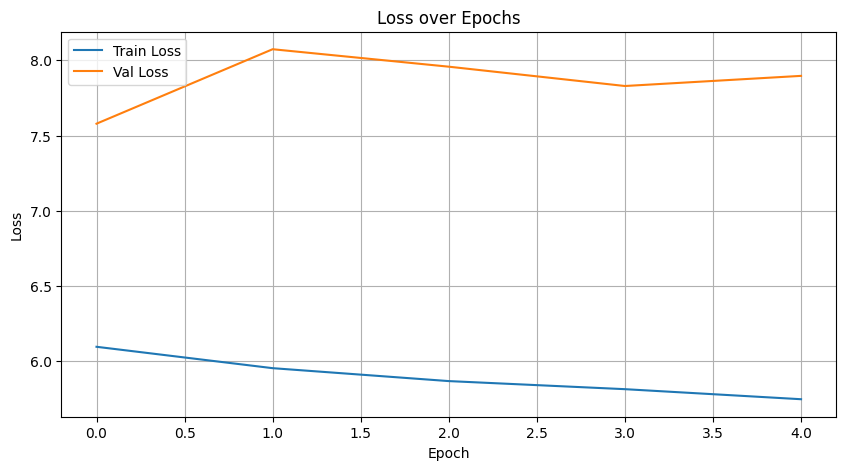

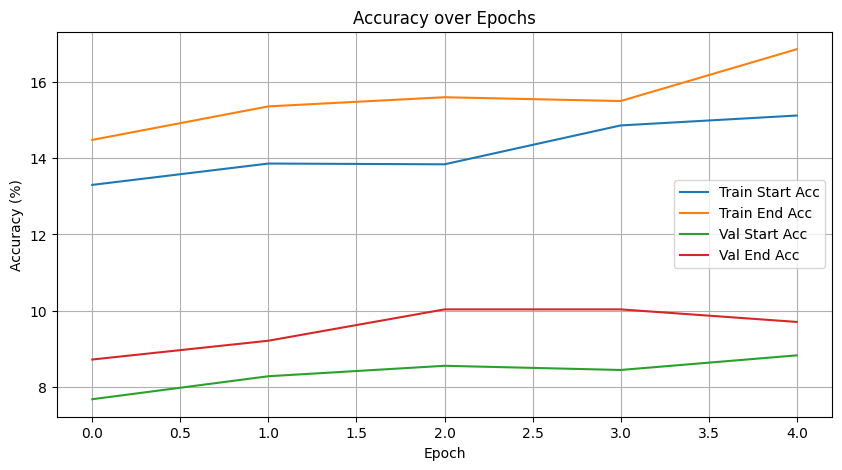

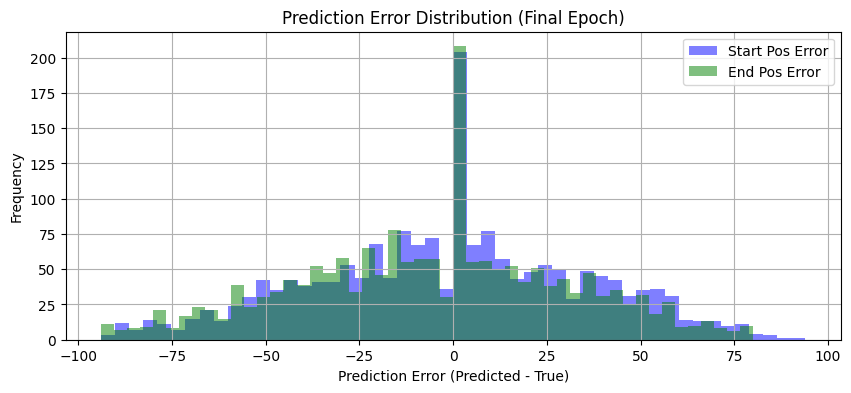

In [20]:
train_model(model, train_loader, val_loader, optimizer, num_epochs=5, device='cpu') 

In [21]:
def evaluate_model(model, test_loader, device="cpu"):
    model.to(device)
    criterion = CrossEntropyLoss()

    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0

    start_errors = []
    end_errors = []

    model.eval()

    with torch.no_grad():
        loop = tqdm(test_loader, desc="Evaluating")

        for batch in loop:
            embeddings, start_positions, end_positions = batch
            embeddings = embeddings.to(device)
            start_positions = start_positions.to(device)
            end_positions = end_positions.to(device)

            # Forward pass
            start_logits, end_logits = model(embeddings)

            # Loss
            loss_start = criterion(start_logits, start_positions)
            loss_end = criterion(end_logits, end_positions)
            loss = loss_start + loss_end
            total_loss += loss.item()

            # Predictions
            pred_start = torch.argmax(start_logits, dim=1)
            pred_end = torch.argmax(end_logits, dim=1)

            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += start_positions.size(0)

            # Store errors
            start_errors.extend((pred_start - start_positions).cpu().numpy())
            end_errors.extend((pred_end - end_positions).cpu().numpy())

            loop.set_postfix({
                'Loss': loss.item(),
                'Acc Start': f"{(correct_start / total) * 100:.2f}%",
                'Acc End': f"{(correct_end / total) * 100:.2f}%"
            })

    # Averages
    avg_loss = total_loss / len(test_loader)
    avg_acc_start = correct_start / total
    avg_acc_end = correct_end / total

    print("\n===== Final Evaluation Results =====")
    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Start Accuracy: {avg_acc_start * 100:.2f}%")
    print(f"End Accuracy: {avg_acc_end * 100:.2f}%")

    # --- Error Histogram ---
    plt.figure(figsize=(10, 4))
    plt.hist(start_errors, bins=50, alpha=0.5, label="Start Pos Error", color="skyblue")
    plt.hist(end_errors, bins=50, alpha=0.5, label="End Pos Error", color="lightgreen")
    plt.xlabel("Prediction Error (Predicted - True)")
    plt.ylabel("Frequency")
    plt.title("Prediction Error Distribution (Evaluation)")
    plt.legend()
    plt.grid(True)
    plt.show()

Evaluating: 100%|██████████| 228/228 [00:08<00:00, 25.50it/s, Loss=9.14, Acc Start=8.83%, Acc End=9.70%] 



===== Final Evaluation Results =====
Test Loss: 7.8965
Start Accuracy: 8.83%
End Accuracy: 9.70%


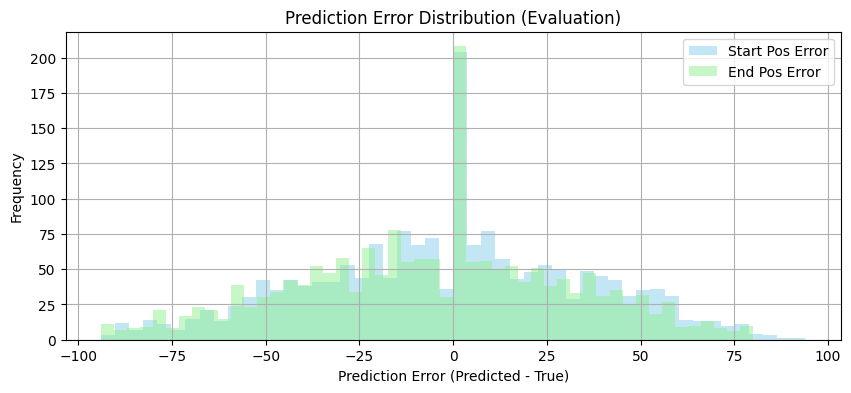

In [22]:
evaluate_model(model, test_loader, device='cpu') 

In [43]:
MAX_LEN = 100  # Set the maximum length for tokens
EMBED_DIM = 100  # GloVe embedding dimension

# --- Step 1: Preprocess context and question ---
def preprocess_input(context, question, glove_embeddings):
    input_text = f"Context: {context} Question: {question}"
    tokens = word_tokenize(input_text.lower())  # Tokenize and lowercase

    # Embed tokens using GloVe
    embedded_tokens = [glove_embeddings.get(token, np.zeros(EMBED_DIM)) for token in tokens]

    # Pad or truncate to MAX_LEN
    pad_len = MAX_LEN - len(embedded_tokens)
    if pad_len > 0:
        embedded_tokens += [np.zeros(EMBED_DIM)] * pad_len
    else:
        embedded_tokens = embedded_tokens[:MAX_LEN]
        tokens = tokens[:MAX_LEN]  # Ensure tokens align with truncated embeddings

    input_tensor = torch.tensor([embedded_tokens], dtype=torch.float32)  # (1, MAX_LEN, EMBED_DIM)
    return input_tensor, tokens

# --- Step 2: Select the best valid span (post-processing) ---
def select_best_span(start_logits, end_logits, max_answer_length=15):
    best_score = float('-inf')
    best_start, best_end = 0, 0

    start_logits = start_logits.squeeze()
    end_logits = end_logits.squeeze()
    seq_len = start_logits.size(0)

    for start_idx in range(seq_len):
        for end_idx in range(start_idx, min(start_idx + max_answer_length, seq_len)):
            score = start_logits[start_idx] + end_logits[end_idx]
            if score > best_score:
                best_score = score
                best_start, best_end = start_idx, end_idx

    return best_start, best_end

# --- Step 3: Extract answer using predicted indices ---
def extract_answer_from_context(start_idx, end_idx, tokens):
    print(f"Extracting answer from tokens between indices {start_idx} and {end_idx}")

    if start_idx < 0 or end_idx < 0 or start_idx >= len(tokens) or end_idx >= len(tokens):
        return "Invalid indices"
    return ' '.join(tokens[start_idx:end_idx + 1])

# --- Step 4: Final prediction pipeline ---
def predict_answer(model, context, question, glove_embeddings, device="cpu"):
    model.eval()
    input_tensor, tokens = preprocess_input(context, question, glove_embeddings)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        start_logits, end_logits = model(input_tensor)

    # ⚠️ Post-processing to find the best (start, end) pair
    best_start_idx, best_end_idx = select_best_span(start_logits[0], end_logits[0])

    # Debugging print: Check the predicted start and end indices
    print(f"Predicted Start Index: {best_start_idx}, Predicted End Index: {best_end_idx}")
    answer = extract_answer_from_context(best_start_idx, best_end_idx, tokens)

    return answer

In [44]:
context = "Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals."
question = "What do modern hunter-gatherers use to produce food in addition to gathering?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 19, Predicted End Index: 22
Extracting answer from tokens between indices 19 and 22
Answer: horticulture and/or keeping animals


In [45]:
context = "His translation of the Bible into the vernacular (instead of Latin) made it more accessible, which had a tremendous impact on the church and German culture. It fostered the development of a standard version of the German language, added several principles to the art of translation, and influenced the writing of an English translation, the Tyndale Bible. His hymns influenced the development of singing in churches. His marriage to Katharina von Bora set a model for the practice of clerical marriage, allowing Protestant clergy to marry."
question = "What development did Luther's hymns translations influence?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 29, Predicted End Index: 30
Extracting answer from tokens between indices 29 and 30
Answer: german culture


In [46]:
context = "Rodin is represented by more than 20 works in the museum collection, making it one of the largest collections of the sculptor's work outside France; these were given to the museum by the sculptor in 1914, as acknowledgement of Britain's support of France in World War I, although the statue of St John the Baptist had been purchased in 1902 by public subscription. Other French sculptors with work in the collection are Hubert Le Sueur, François Girardon, Michel Clodion, Jean-Antoine Houdon, Jean-Baptiste Carpeaux and Jules Dalou."
question = "In which year were Rodin's works given to the V&A?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 67, Predicted End Index: 67
Extracting answer from tokens between indices 67 and 67
Answer: 1902


In [47]:
context = "The UMC is also a member of the Wesleyan Holiness Consortium, which seeks to reconceive and promote Biblical holiness in today\'s Church. It is also active in the World Methodist Council, an interdenominational group composed of various churches in the tradition of John Wesley to promote the Gospel throughout the world. On July 18, 2006, delegates to the World Methodist Council voted unanimously to adopt the Joint Declaration on the Doctrine of Justification, which was approved in 1999 by the Vatican and the Lutheran World Federation."
question = "Which group seeks to reconceive and promote Biblical holiness in today's church?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 87, Predicted End Index: 87
Extracting answer from tokens between indices 87 and 87
Answer: 1999


In [52]:
context = "Developer William Smilie created the nation's first planned aviation community."
question = "Who create the nation's first planned aviation community?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 4, Predicted End Index: 4
Extracting answer from tokens between indices 4 and 4
Answer: smilie
